<a class="anchor" id="0">

# **0. Setup & Imports**

[Back to TOC](#toc)
</a>


In [1]:
%pip install wordcloud nltk  
%pip install xgboost
%pip install transformers
%pip install torch
%pip install sentencepiece
%pip install tokenizers
%pip install -q langchain langchain-openai langchain-core langchain-community
%pip install sentencepiece tiktoken --upgrade
%pip install transformers[torch]
%pip install 'accelerate>=1.1.0' --upgrade

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.comNote: you may need to restart the kernel to use updated packages.

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to resta

ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [2]:
%run tm_lib.py

from tm_lib import (
    FinancialTextPreprocessor,
    StratifiedKFoldTrainer,
    BoWFeatureExtractor,
    Word2VecFeatureExtractor,
    TokenizedTweetDataset,
    WeightedTrainer,
    TraditionalMLClassifier,
    TransformerClassifier,
    DecoderClassifier,
    ModelBundle
)

from sklearn.metrics import classification_report

# Classes used in the notebook

The classes implemented and used in this notebook are in [tm_lib.py](tm_lib.py), which is imported at the top of the notebook.

# Functions used in the notebook

In [3]:
def show_before_after_preproc(preprocessor, texts, max_display_length=100):
    """
    Simple before/after display without all the step details
    
    Args:
        preprocessor: Your FinancialTextPreprocessor instance
        texts: List of texts to process
        max_display_length: Truncate display to this length
    """
    print("\n" + "="*80)
    print("Before and After Preprocessing")
    print("="*80)
    
    for i, text in enumerate(texts, 1):
        processed = preprocessor._preprocess_single(text)
        
        # Truncate for display
        orig_display = text[:max_display_length] + "..." if len(text) > max_display_length else text
        proc_display = processed[:max_display_length] + "..." if len(processed) > max_display_length else processed
        
        print(f"\n{i}. BEFORE: {orig_display}")
        print(f"   AFTER:  {proc_display}")
        print(f"   Tokens: {len(processed.split())} (was {len(text.split())})")
    
    print("\n" + "="*80)

def run_cv(model, preprocessor, vectorizer, texts, labels, n_splits=5, label=""):
    """Run stratified K-Fold CV for a given model/preprocessor/vectorizer combo."""
    skf          = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    texts        = np.array(texts)
    labels       = np.array(labels)
    fold_records = []

    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels), start=1):
        X_train_raw, X_val_raw = texts[train_idx], texts[val_idx]
        y_train,     y_val     = labels[train_idx], labels[val_idx]

        # Preprocess
        X_train_proc = preprocessor.transform(X_train_raw)
        X_val_proc   = preprocessor.transform(X_val_raw)

        # Vectorize — fit only on train
        X_train_vec  = vectorizer.fit_transform(X_train_proc)
        X_val_vec    = vectorizer.transform(X_val_proc)

        # Class weights
        classes     = np.unique(y_train)
        weights     = compute_class_weight('balanced', classes=classes, y=y_train)
        weight_dict = dict(zip(classes, weights))

        # Clone and fit model
        import copy
        m = copy.deepcopy(model)
        if hasattr(m, 'class_weight'):
            m.set_params(class_weight=weight_dict)
            m.fit(X_train_vec, y_train)
        else:
            sample_weights = np.array([weight_dict[y] for y in y_train])
            m.fit(X_train_vec, y_train, sample_weight=sample_weights)

        # Evaluate
        y_pred   = m.predict(X_val_vec)
        f1_macro = f1_score(y_val, y_pred, average='macro', zero_division=0)
        acc      = accuracy_score(y_val, y_pred)

        print(f"Fold {fold} — Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f}")
        fold_records.append({'f1_macro': f1_macro, 'accuracy': acc,
                             'model': m, 'vectorizer': copy.deepcopy(vectorizer)})

    mean_f1 = np.mean([r['f1_macro'] for r in fold_records])
    std_f1  = np.std([r['f1_macro']  for r in fold_records])
    print(f"\nMean Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")
    return fold_records    

def pre_tune_all_models_once(
    texts, labels, 
    traditional_preprocessor,
    feature_extractor,
    save_dir='./tuned_models', 
    cv_inner=3, 
    test_size=0.15
):
    
    if isinstance(texts, pd.Series):
        texts = texts.astype(str).to_numpy(dtype=object)
    else:
        texts = np.asarray(list(texts), dtype=object)

    if isinstance(labels, pd.Series):
        labels = labels.astype(np.int64).to_numpy()
    else:
        labels = np.asarray(labels, dtype=np.int64)

    os.makedirs(save_dir, exist_ok=True)

    print("\n" + "="*80)
    print("PRE-PROCESSING DATA FOR ONE-TIME TUNING")
    print("="*80)

    y = labels
    
    # Process texts for traditional models ONLY
    processed_texts = traditional_preprocessor.transform(texts)
    
    print(f"Class distribution: {np.bincount(y)}")

    # Split for traditional models (using processed texts)
    X_train_texts, X_test_texts, y_train, y_test = train_test_split(
        processed_texts, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    # Traditional models (use preprocessed texts)
    model_types = ['logistic_regression', 'random_forest', 'xgboost']
    tuned_models = {}

    for model_type in model_types:
        print("\n" + "="*60)
        print(f"PRE-TUNING: {model_type.upper()}")
        print("="*60)

        bundle_file = os.path.join(save_dir, f"{model_type}_bundle.pkl")
        params_file = os.path.join(save_dir, f"{model_type}_best_params.json")

        if os.path.exists(bundle_file):
            bundle = ModelBundle.load(bundle_file)
            tuned_models[model_type] = bundle
            continue

        # Train/val split
        X_tr_texts, X_val_texts, y_tr, y_val = train_test_split(
            X_train_texts, y_train,
            test_size=0.2,
            stratify=y_train,
            random_state=42
        )

        vectorizer = deepcopy(feature_extractor)
        X_tr = vectorizer.fit_transform(X_tr_texts)
        X_val = vectorizer.transform(X_val_texts)

        classifier = TraditionalMLClassifier(model_type)
        tuned_model, _ = classifier.tune_before_cv(
            X_tr, y_tr,
            cv_inner=cv_inner,
            test_size=0
        )

        temp_bundle = ModelBundle(
            model=tuned_model,
            preprocessor=traditional_preprocessor,  # Keep traditional
            vectorizer=vectorizer,
            is_transformer=False
        )

        y_pred = temp_bundle.predict(X_test_texts)
        test_f1_macro = f1_score(y_test, y_pred, average='macro')
        test_f1_per_class = f1_score(y_test, y_pred, average=None)

        print(f"Macro F1: {test_f1_macro:.4f}")

        bundle = ModelBundle(
            model=tuned_model,
            preprocessor=traditional_preprocessor,  # Keep traditional
            vectorizer=vectorizer,
            is_transformer=False
        )

        bundle.metrics = {
            "macro_f1": test_f1_macro,
            "bearish_f1": test_f1_per_class[0],
            "bullish_f1": test_f1_per_class[1],
            "neutral_f1": test_f1_per_class[2],
        }

        bundle.save(bundle_file)
        with open(params_file, "w") as f:
            json.dump({
                "model_type": model_type,
                "metrics": bundle.metrics,
                "timestamp": datetime.now().isoformat()
            }, f, indent=2)

        tuned_models[model_type] = bundle
        print(f"Saved → {bundle_file}")

    # transformer models (use raw texts, as they will handle tokenization internally)
    print("\n" + "="*80)
    print("PRE-TUNING TRANSFORMER MODELS")
    print("="*80)

    raw_texts = texts.tolist() # raw texts for transformer models (BERT will handle tokenization)

    # Now split the BERT-processed texts
    raw_train_texts, raw_test_texts, y_train_trans, y_test_trans = train_test_split(
        raw_texts,  
        y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    neural_configs = [
    {"name": "bert",       "kind": "encoder", "model_name": "google-bert/bert-base-uncased"},
    {"name": "distilbert", "kind": "encoder", "model_name": "distilbert-base-uncased"},
    {"name": "finbert",    "kind": "encoder", "model_name": "yiyanghkust/finbert-tone", "tokenizer_name": "bert-base-uncased"},
    {"name": "flan_t5",    "kind": "decoder", "model_name": "google/flan-t5-small"},
    ]

    for config in neural_configs:
        model_type = config["name"]

        print("\n" + "="*60)
        print(f"PRE-TUNING: {model_type.upper()}")
        print("="*60)

        bundle_file = os.path.join(save_dir, f"{model_type}_bundle.pkl")
        params_file = os.path.join(save_dir, f"{model_type}_best_params.json")

        if os.path.exists(bundle_file):
            print(f"Loading existing bundle: {model_type}")
            bundle = ModelBundle.load(bundle_file)
            tuned_models[model_type] = bundle
            continue

        train_texts_split, val_texts_split, train_labels_split, val_labels_split = train_test_split(
            raw_train_texts,
            y_train_trans,
            test_size=0.2,
            stratify=y_train_trans,
            random_state=42
        )

        if config["kind"] == "encoder":
            classifier = TransformerClassifier(
                model_name=config["model_name"],
                tokenizer_name=config.get("tokenizer_name"),
                batch_size=16,
                max_length=128
            )
            classifier.fine_tune(
                train_texts=train_texts_split,
                train_labels=train_labels_split,
                val_texts=val_texts_split,
                val_labels=val_labels_split,
                epochs=3,
                use_class_weights=True,
                use_hf_trainer=False
            )

            bundle = ModelBundle(
                model=classifier,
                preprocessor=None,
                vectorizer=None,
                is_transformer=True,
                is_decoder=False
            )

        else:  # decoder (FLAN-T5)
            classifier = DecoderClassifier(
                model_name=config["model_name"],
                max_input_length=128,
                max_target_length=8,
                batch_size=8,
                learning_rate=3e-4
            )
            classifier.fit(
                train_texts=train_texts_split,
                train_labels=train_labels_split.tolist(),
                val_texts=val_texts_split,
                val_labels=val_labels_split.tolist(),
                epochs=3
            )

            bundle = ModelBundle(
                model=classifier,
                preprocessor=None,
                vectorizer=None,
                is_transformer=False,
                is_decoder=True
            )

        # Evaluate on held-out test set
        y_pred = bundle.predict(raw_test_texts)

        test_f1_macro = f1_score(y_test_trans, y_pred, average="macro")
        test_f1_per_class = f1_score(y_test_trans, y_pred, average=None)

        print(f"Macro F1: {test_f1_macro:.4f}")

        bundle.metrics = {
            "macro_f1": test_f1_macro,
            "bearish_f1": test_f1_per_class[0],
            "bullish_f1": test_f1_per_class[1],
            "neutral_f1": test_f1_per_class[2]
        }

        bundle.save(bundle_file)
        with open(params_file, "w") as f:
            json.dump({
                "model_type": model_type,
                "metrics": bundle.metrics,
                "timestamp": datetime.now().isoformat()
            }, f, indent=2)

        tuned_models[model_type] = bundle
        print(f"Saved → {bundle_file}")

    print("\nAll models saved as bundles in:", save_dir)
    return tuned_models    



<a class="anchor" id="1">

# **1. Load Data**

[Back to TOC](#toc)
</a>


In [4]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

#Check basic info about the dataset

print(train.info())
print('\nMissing values:\n', train.isnull().sum())
print('\nDuplicate tweets:', train.duplicated(subset='text').sum())

Train shape: (9543, 2)
Test shape : (2388, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB
None

Missing values:
 text     0
label    0
dtype: int64

Duplicate tweets: 0


<a class="anchor" id="2">

# **2. Data Exploration**

[Back to TOC](#toc)
</a>

As we can see, the dataset contains 7613 training samples and 3263 test samples. Each sample consists of a tweet (text) and a label indicating wether the tweet is bearish (0) or bullish (1), or neutral (2). There are no missing values in the dataset nor duplicate tweets, which is a good initial sign for data quality.

<a class="anchor" id="2_1">

## **2.1 Class Distribution**

[Back to TOC](#toc)
</a>

Now let's check the distribution of the classes in the training set to see if we have any imbalance issues.

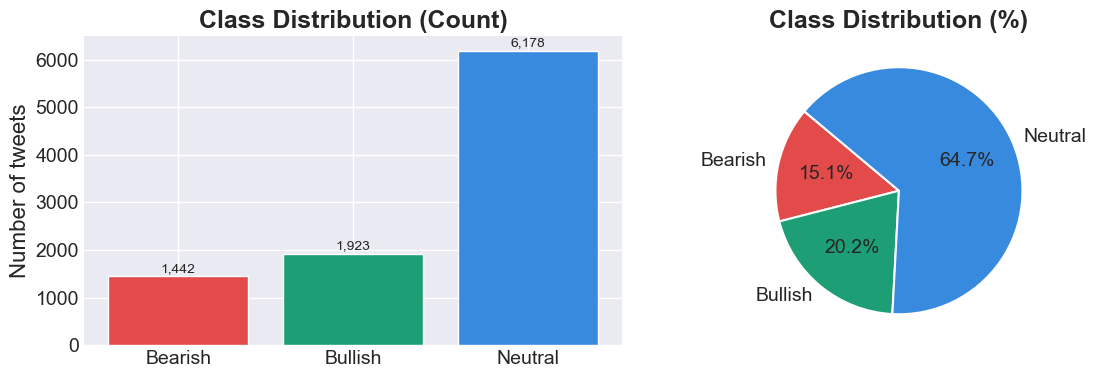

In [5]:

plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.labelsize': 16,      # X/Y label size
    'axes.titlesize': 18,      # Subplot title size
    'xtick.labelsize': 14,     # X-axis tick labels
    'ytick.labelsize': 14,     # Y-axis tick labels
    'legend.fontsize': 14,     # Legend text size
    'legend.title_fontsize': 16
})

counts = train['label'].value_counts().sort_index()
counts.index = [LABEL_MAP[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[i] for i in sorted(PALETTE)],
                   edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of tweets')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[i] for i in sorted(PALETTE)],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_2">

## **2.2 Tweet Length**

[Back to TOC](#toc)
</a>

Next, let's analyze the length of the tweets in terms of number of characters and words to understand the typical tweet structure in our dataset.

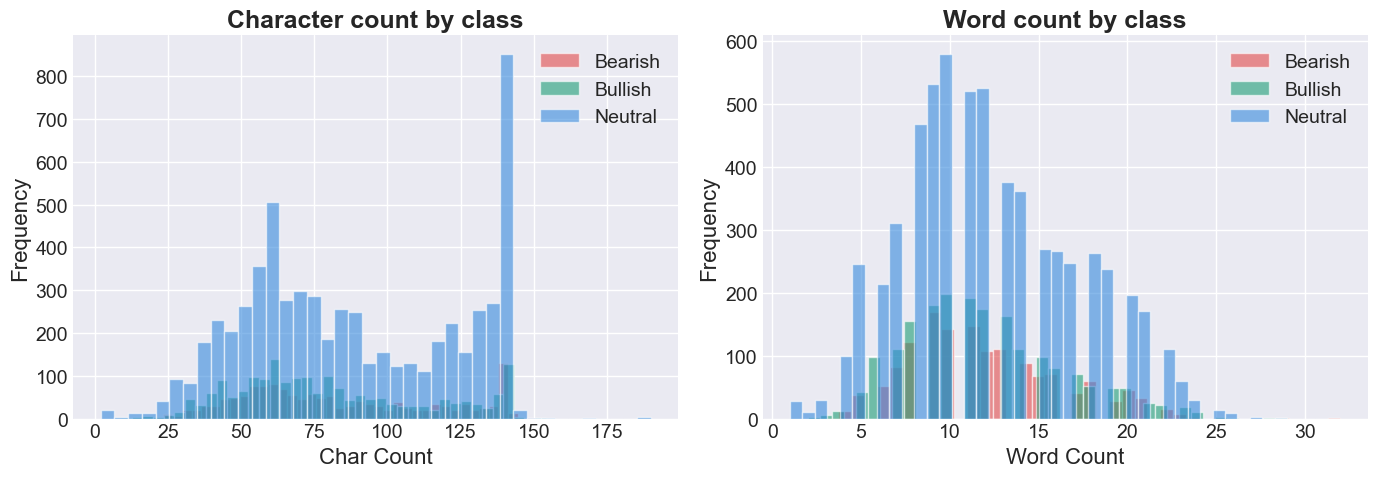

In [6]:
train['char_count'] = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()
train['label_name'] = train['label'].map(LABEL_MAP)

# Your existing code (histograms)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax, title in [
    ('char_count', axes[0], 'Character count by class'),
    ('word_count', axes[1], 'Word count by class')
]:
    for lid, lname in LABEL_MAP.items():
        ax.hist(train[train['label']==lid][metric],
                bins=40, alpha=0.6, label=lname, color=PALETTE[lid])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric.replace('_',' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('length_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# # Boxplots (text will inherit rcParams, but you can also enlarge more)
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.boxplot(data=train, x='label_name', y='char_count', order=order, palette=pal, ax=axes[0])
# axes[0].set_title('Character Count per Class', fontweight='bold', fontsize=18)  # explicit size
# axes[0].set_xlabel('', fontsize=16)
# axes[0].set_ylabel('Character Count', fontsize=16)
# axes[0].tick_params(axis='both', labelsize=14)

# sns.boxplot(data=train, x='label_name', y='word_count', order=order, palette=pal, ax=axes[1])
# axes[1].set_title('Word Count per Class', fontweight='bold', fontsize=18)
# axes[1].set_xlabel('', fontsize=16)
# axes[1].set_ylabel('Word Count', fontsize=16)
# axes[1].tick_params(axis='both', labelsize=14)

# plt.tight_layout()
# plt.savefig('length_boxplots.png', dpi=150, bbox_inches='tight')
# plt.show()

<a class="anchor" id="2_3">

## **2.3 Top Tokens per Class**

[Back to TOC](#toc)
</a>

Next, let's look at the most common words used in each class to get a sense of the language patterns associated with bullish, bearish, and neutral tweets.

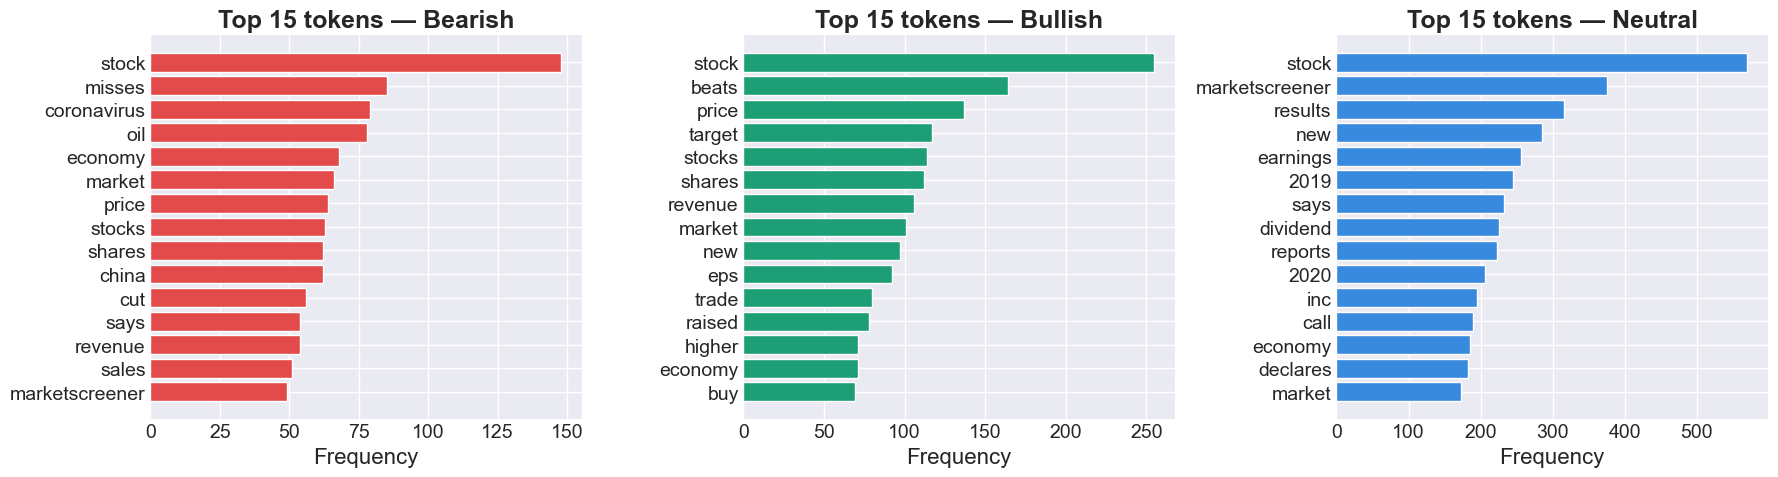

In [7]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [t for t in text.split()
              if t not in STOP_WORDS and len(t) > 2]
    return tokens

train['tokens'] = train['text'].apply(basic_clean)

TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    all_tokens = [tok for toks in train[train['label']==label_id]['tokens'] for tok in toks]
    words, freqs = zip(*Counter(all_tokens).most_common(TOP_N))
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=PALETTE[label_id], edgecolor='white')
    ax.set_title(f'Top {TOP_N} tokens — {LABEL_MAP[label_id]}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_tokens_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_4">

## **2.4 Word Clouds**

[Back to TOC](#toc)
</a>

Next, let's visualize the most common words in each class using word clouds to get a more intuitive understanding of the language used in bullish, bearish, and neutral tweets.

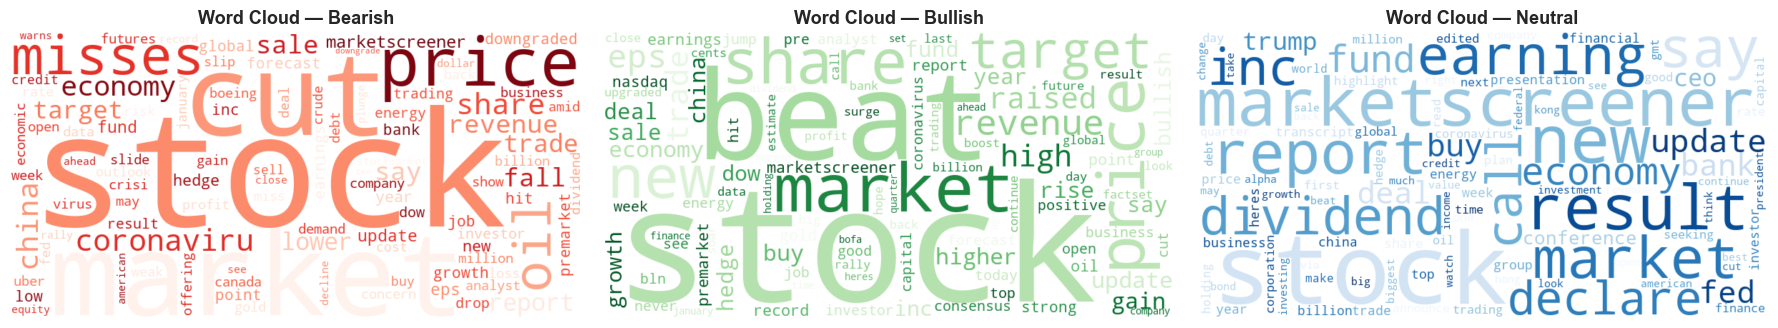

In [8]:
cmaps = {0: 'Reds', 1: 'Greens', 2: 'Blues'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    corpus = ' '.join(tok for toks in train[train['label']==label_id]['tokens'] for tok in toks)
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=cmaps[label_id],
                   max_words=100,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {LABEL_MAP[label_id]}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_5">

## **2.5 Hashtags, mentions & cashtags**

[Back to TOC](#toc)
</a>

Next, let's analyze the usage of hashtags, mentions, and cashtags in the tweets to see if there are any patterns that could be useful for classification.

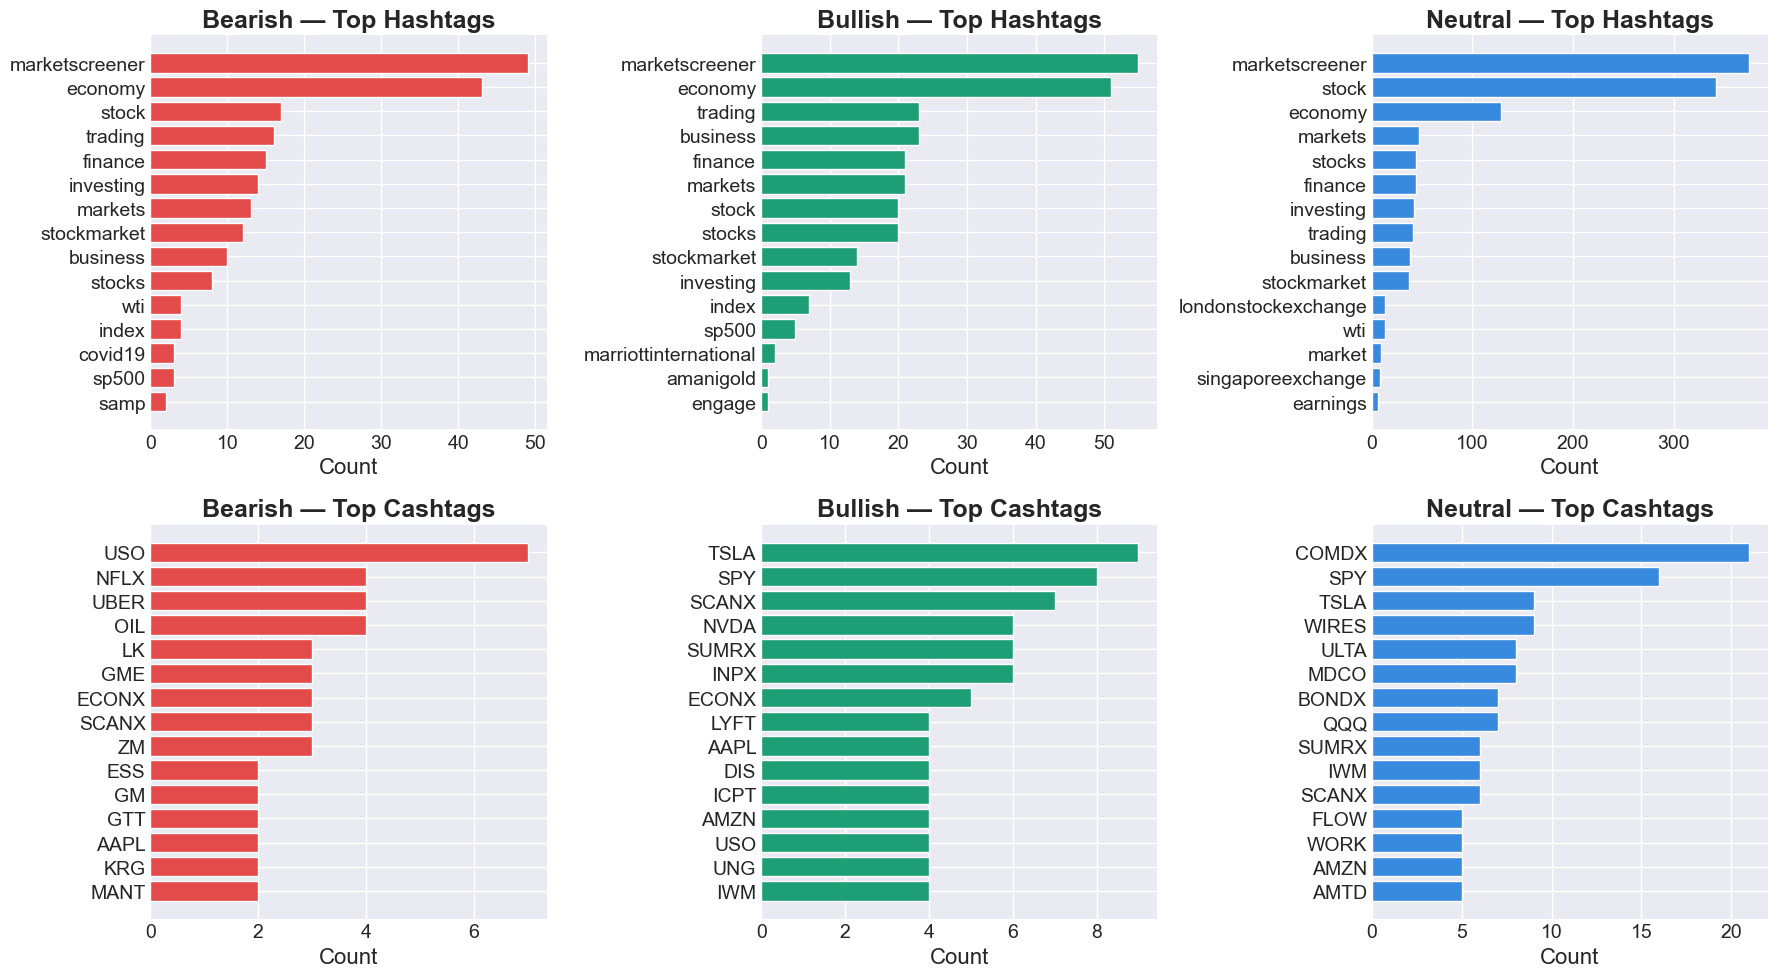

In [9]:
train['hashtags']   = train['text'].apply(lambda t: re.findall(r'#(\w+)', t.lower()))
train['mentions']   = train['text'].apply(lambda t: re.findall(r'@(\w+)', t.lower()))
train['n_hashtags'] = train['hashtags'].str.len()
train['n_mentions'] = train['mentions'].str.len()
train['has_url']    = train['text'].str.contains(r'https?://\S+|www\.\S+', regex=True)
train['has_cashtag']= train['text'].str.contains(r'\$[A-Z]{2,5}', regex=True)

TOP_N = 15

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, label_id in enumerate(sorted(LABEL_MAP)):
    subset = train[train['label'] == label_id]

    # ----- HASHTAGS -----
    hashtags = [h for hs in subset['hashtags'] for h in hs]
    if hashtags:
        words, freqs = zip(*Counter(hashtags).most_common(TOP_N))
        axes[0, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[0, i].set_title(f'{LABEL_MAP[label_id]} — Top Hashtags', fontweight='bold')
        axes[0, i].set_xlabel('Count')

    # ----- CASHTAGS -----
    cashtags = re.findall(r'\$([A-Z]{2,5})', ' '.join(subset['text'].tolist()))
    if cashtags:
        words, freqs = zip(*Counter(cashtags).most_common(TOP_N))
        axes[1, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[1, i].set_title(f'{LABEL_MAP[label_id]} — Top Cashtags', fontweight='bold')
        axes[1, i].set_xlabel('Count')

plt.tight_layout()
plt.savefig('top_hashtags_cashtags_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('EXPLORATION SUMMARY\n')

for label, group in train.groupby('label_name'):
    print(f'{label.upper()}')
    print(f'Avg chars  : {group["char_count"].mean():.0f}')
    print(f'Avg words  : {group["word_count"].mean():.0f}')
    print(f'Has URL    : {group["has_url"].mean()*100:.1f}%')
    print(f'Has cashtag: {group["has_cashtag"].mean()*100:.1f}%\n')

EXPLORATION SUMMARY

BEARISH
Avg chars  : 83
Avg words  : 12
Has URL    : 44.3%
Has cashtag: 13.7%

BULLISH
Avg chars  : 80
Avg words  : 12
Has URL    : 39.1%
Has cashtag: 24.6%

NEUTRAL
Avg chars  : 88
Avg words  : 12
Has URL    : 49.8%
Has cashtag: 12.0%



<a class="anchor" id="3">

# **3. Data Preprocessing**

[Back to TOC](#toc)
</a>

In this section, we will apply a series of preprocessing steps to our text data to clean and normalize it before feeding it into our machine learning models. This includes lowercasing, removing punctuation, stop words, and performing stemming or lemmatization.

Example Usage

In [11]:
# Define the preprocessor instance
preprocessor = FinancialTextPreprocessor(use_stemming=False)

tweets_to_test = train['text'].sample(3, random_state=42).tolist()

show_before_after_preproc(preprocessor, tweets_to_test)


Before and After Preprocessing

1. BEFORE: When staffers in WeWork's New York City headquarters received a calendar invite for a mandatory meet...
   AFTER:  staffer weworks new york city headquarters received calendar invite mandatory meeting note
   Tokens: 12 (was 20)

2. BEFORE: ADMA Biologics down 9% premarket after pricing equity offering
   AFTER:  adma biologics down num_percent premarket pricing equity offering
   Tokens: 8 (was 9)

3. BEFORE: Illegal Tender podcast: What it was like to befriend convicted socialite scammer Anna Delvey
   AFTER:  illegal tender podcast like befriend convicted socialite scammer anna delvey
   Tokens: 10 (was 14)



<a class="anchor" id="4">

# **4. Corpus Split**

[Back to TOC](#toc)
</a>

Corpus split is a crucial step not only in machine learning pipelines but also in NLP pipelines as it allows us to evaluate our models on unseen data and prevent overfitting. In this section, we will apply a stratified k-fold cross-validation approach to split our training data.

Example Usage of FinancialTextPreprocessor Alongside Stratified K-Fold Cross-Validation:

In [12]:
df     = pd.read_csv('train.csv')
texts  = df['text'].astype(str).to_numpy(dtype=object)
labels = df['label'].astype(np.int64).to_numpy()

print(f"Dataset shape: {len(texts)} samples")
print(f"Class distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SENTIMENT = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

# Logistic Regression

results_lr = run_cv(
    model       = LogisticRegression(max_iter=1000, random_state=42),
    preprocessor= FinancialTextPreprocessor(use_stemming=False),
    vectorizer  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    texts       = texts,
    labels      = labels,
    label       = "EXAMPLE 1: Logistic Regression",
)


# Random Forest

results_rf = run_cv(
    model       = RandomForestClassifier(n_estimators=100, random_state=42),
    preprocessor= FinancialTextPreprocessor(use_stemming=False),
    vectorizer  = TfidfVectorizer(max_features=5000),
    texts       = texts,
    labels      = labels,
    label       = "EXAMPLE 2: Random Forest",
)


# Stemming vs Lemmatization

for use_stemming, name in [(True, 'Stemming'), (False, 'Lemmatization')]:
    run_cv(
        model       = LogisticRegression(max_iter=1000, random_state=42),
        preprocessor= FinancialTextPreprocessor(use_stemming=use_stemming),
        vectorizer  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
        texts       = texts[:1000],
        labels      = labels[:1000],
        n_splits    = 3,
        label       = f"EXAMPLE 3: {name}",
    )


# Predictions using best fold

print("\n" + "="*60)
print("EXAMPLE 4: Predictions on New Data (best LR fold)")
print("="*60)

best       = max(results_lr, key=lambda r: r['f1_macro'])
best_model = best['model']
best_vec   = best['vectorizer']

new_texts  = [
    "$AAPL upgraded to buy at Morgan Stanley, price target raised",
    "$TSLA shares cut at Goldman on production concerns",
    "Netflix reports mixed earnings, user growth beats expectations",
]

preprocessor = FinancialTextPreprocessor(use_stemming=False)
new_proc     = preprocessor.transform(new_texts)
new_vec      = best_vec.transform(new_proc)
predictions  = best_model.predict(new_vec)

for text, pred in zip(new_texts, predictions):
    print(f"Text      : {text[:60]}...")
    print(f"Prediction: {SENTIMENT[pred]} (Class {pred})\n")


# Comparison summary

print("\n" + "="*60)
print("EXAMPLE 5: Model Comparison (Macro F1)")
print("="*60)

comparison = pd.DataFrame({
    'Logistic Regression': [r['f1_macro'] for r in results_lr],
    'Random Forest'      : [r['f1_macro'] for r in results_rf],
}, index=[f"Fold {i+1}" for i in range(5)])

comparison.loc['Mean'] = comparison.mean().round(4)
comparison.loc['Std']  = comparison.std().round(4)
print(comparison)

Dataset shape: 9543 samples
Class distribution: {np.int64(0): np.int64(1442), np.int64(1): np.int64(1923), np.int64(2): np.int64(6178)}

EXAMPLE 1: Logistic Regression
Fold 1 — Accuracy: 0.7884 | Macro F1: 0.7275
Fold 2 — Accuracy: 0.7821 | Macro F1: 0.7159
Fold 3 — Accuracy: 0.7936 | Macro F1: 0.7359
Fold 4 — Accuracy: 0.7825 | Macro F1: 0.7216
Fold 5 — Accuracy: 0.7820 | Macro F1: 0.7142

Mean Macro F1: 0.7230 ± 0.0079

EXAMPLE 2: Random Forest
Fold 1 — Accuracy: 0.7968 | Macro F1: 0.6952
Fold 2 — Accuracy: 0.7968 | Macro F1: 0.6925
Fold 3 — Accuracy: 0.8130 | Macro F1: 0.7194
Fold 4 — Accuracy: 0.8056 | Macro F1: 0.7060
Fold 5 — Accuracy: 0.7972 | Macro F1: 0.6897

Mean Macro F1: 0.7006 ± 0.0109

EXAMPLE 3: Stemming
Fold 1 — Accuracy: 0.8174 | Macro F1: 0.8138
Fold 2 — Accuracy: 0.7838 | Macro F1: 0.7816
Fold 3 — Accuracy: 0.8408 | Macro F1: 0.8395

Mean Macro F1: 0.8116 ± 0.0237

EXAMPLE 3: Lemmatization
Fold 1 — Accuracy: 0.8054 | Macro F1: 0.8022
Fold 2 — Accuracy: 0.7688 | Macro

<a class="anchor" id="5">

# **5. Feature Engineering**

[Back to TOC](#toc)
</a>

In this section, we will create new features from our text data that could help improve the performance of our NLP models. This includes features like TF-IDF scores, word embeddings, sentiment scores, and more.

<a class="anchor" id="5.1">

## **5.1 Bag of Words Feature Extraction alongside TF-IDF**

[Back to TOC](#toc)
</a>

Example Usage of BoWFeatureExtractor Alongside TF-IDF:

In [13]:
# Define a smaller subset of texts for quick testing
raw_subset = train['text'].values[:1000] 

print("\n" + "="*60)
print("EXAMPLE 6: Using BoWFeatureExtractor")
print("="*60)
bow_extractor = BoWFeatureExtractor(max_features=5000, use_ngrams=True, use_svd=False)
X_bow = bow_extractor.fit_transform(texts)
print(f"BoW feature matrix shape: {X_bow.shape}")
bow_extractor.get_top_features(n=10)    


EXAMPLE 6: Using BoWFeatureExtractor
BoW feature matrix shape: (9543, 5000)

Top features by IDF (most distinctive):
  year yield at: 9.065
  yield at: 9.065
  credit up: 9.065
  year yield: 9.065
  rds: 8.777
  pool: 8.777
  okta: 8.777
  levi: 8.777
  wolfe: 8.777
  renault: 8.777


array(['year yield at', 'yield at', 'credit up', 'year yield', 'rds',
       'pool', 'okta', 'levi', 'wolfe', 'renault'], dtype=object)

<a class="anchor" id="5.2">

## **5.2 Word Embeddings (word2vec)**

[Back to TOC](#toc)
</a>

Example usage of Word2VecFeatureExtractor:

Training Word2Vec on 9543 documents...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Document vectors shape: (9543, 100)
Words most similar to 'upgrade': [('program,', 0.9939159154891968), ('ascend', 0.9936084747314453), ('downgrade', 0.9934064745903015), ('Ebay', 0.9929789900779724), ('multimonth', 0.9925695061683655), ('tumbling', 0.9923698902130127), ('maker', 0.9918907880783081), ('plunging', 0.9914951324462891), ('SunPower', 0.9912126064300537), ('poison', 0.9907699227333069)]


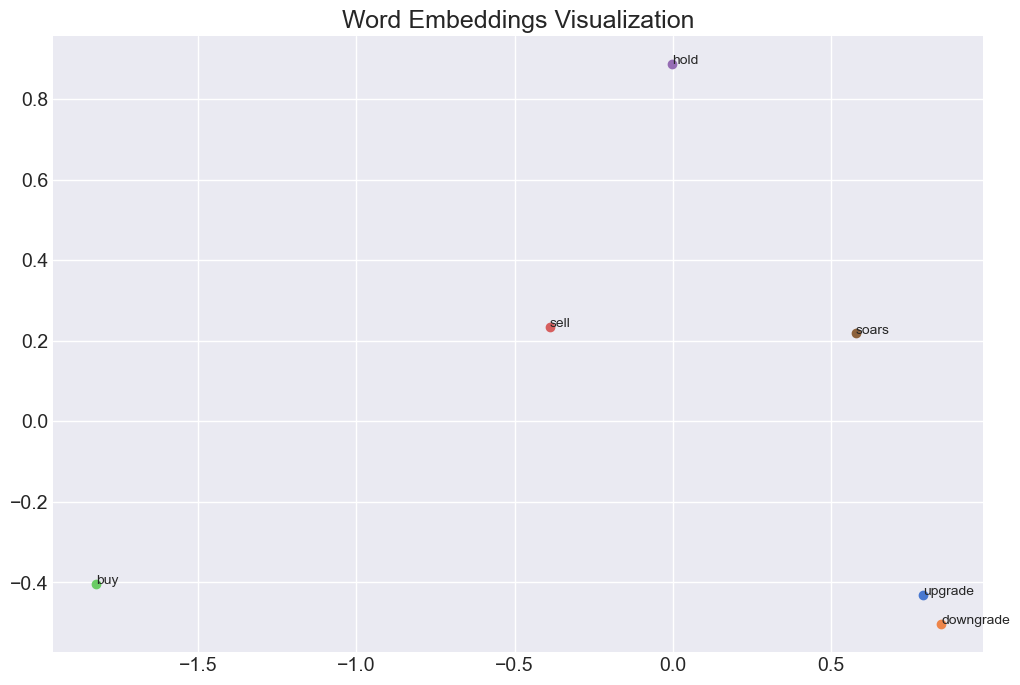

In [14]:
w2v_extractor = Word2VecFeatureExtractor(vector_size=100)
w2v_extractor.fit(texts)
doc_vectors = w2v_extractor.transform(texts)
print(f"Document vectors shape: {doc_vectors.shape}")
similar_words = w2v_extractor.get_most_similar_words('upgrade')
print(f"Words most similar to 'upgrade': {similar_words}")
w2v_extractor.visualize_embeddings(['upgrade', 'downgrade', 'buy', 'sell', 'hold', 'soars'], save_path='word_embeddings.png')

<a class="anchor" id="5.3">

## **5.3 Pre-tuning Models**

[Back to TOC](#toc)
</a>

### Pre-tuning for all models

In [15]:
feature_extractor = Word2VecFeatureExtractor()
tuned_models = pre_tune_all_models_once(texts, labels, preprocessor, feature_extractor)


PRE-PROCESSING DATA FOR ONE-TIME TUNING
Class distribution: [1442 1923 6178]

PRE-TUNING: LOGISTIC_REGRESSION

PRE-TUNING: RANDOM_FOREST

PRE-TUNING: XGBOOST

PRE-TUNING TRANSFORMER MODELS

PRE-TUNING: BERT
Model : google-bert/bert-base-uncased
Tokenizer: google-bert/bert-base-uncased
Device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: {np.int64(0): np.float64(2.205), np.int64(1): np.float64(1.655), np.int64(2): np.float64(0.515)}
Epoch 1/3 — Loss: 0.6892 | Val Macro F1: 0.7647
  New best model (F1=0.7647)
Epoch 2/3 — Loss: 0.3569 | Val Macro F1: 0.8143
  New best model (F1=0.8143)
Epoch 3/3 — Loss: 0.2134 | Val Macro F1: 0.8321
  New best model (F1=0.8321)

Best validation F1 during training: 0.8321
Validation F1 after restoring best checkpoint: 0.8321
Macro F1: 0.8199
Saved → ./tuned_models\bert_bundle.pkl

PRE-TUNING: DISTILBERT
Loading existing bundle: distilbert

PRE-TUNING: FINBERT
Loading existing bundle: finbert

PRE-TUNING: FLAN_T5
Loading existing bundle: flan_t5

All models saved as bundles in: ./tuned_models


<a class="anchor" id="6">

# **6. Model Evaluation**

[Back to TOC](#toc)
</a>

In this section, we will evaluate the performance of our trained models using various metrics such as accuracy, precision, recall, and F1-score. We will also compare the results across different models to identify which one performs best on our financial market tweet sentiment analysis.

In [16]:
class BatchModelEvaluator:

    def __init__(self, model_dir, n_splits=5, random_state=42):
        self.model_dir = model_dir
        self.skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )
        self.results = {}

    def evaluate_all(self, texts, labels):
        y = np.asarray(labels, dtype=np.int64)
        texts = list(texts)

        model_files = sorted(
            f for f in os.listdir(self.model_dir)
            if f.endswith("_bundle.pkl")
        )

        for file in model_files:
            path = os.path.join(self.model_dir, file)

            try:
                loaded = ModelBundle.load(path)
            except Exception as e:
                print(f"[SKIP] Could not load {file}: {e}")
                continue

            if not isinstance(loaded, ModelBundle):
                print(f"[SKIP] {file} is {type(loaded).__name__}, not ModelBundle")
                continue

            bundle = loaded

            macro_precision_scores = []
            macro_recall_scores = []
            macro_f1_scores = []
            accuracy_scores = []

            bearish_precision_scores = []
            bearish_recall_scores = []
            bearish_f1_scores = []

            bullish_precision_scores = []
            bullish_recall_scores = []
            bullish_f1_scores = []

            neutral_precision_scores = []
            neutral_recall_scores = []
            neutral_f1_scores = []

            for fold, (_, val_idx) in enumerate(self.skf.split(texts, y)):
                X_val = [texts[i] for i in val_idx]
                y_val = y[val_idx]

                preds = bundle.predict(X_val)

                macro_precision_scores.append(
                    precision_score(y_val, preds, average="macro", zero_division=0)
                )
                macro_recall_scores.append(
                    recall_score(y_val, preds, average="macro", zero_division=0)
                )
                macro_f1_scores.append(
                    f1_score(y_val, preds, average="macro", zero_division=0)
                )
                accuracy_scores.append(
                    accuracy_score(y_val, preds)
                )

                per_class_precision = precision_score(
                    y_val, preds, average=None, labels=[0, 1, 2], zero_division=0
                )
                per_class_recall = recall_score(
                    y_val, preds, average=None, labels=[0, 1, 2], zero_division=0
                )
                per_class_f1 = f1_score(
                    y_val, preds, average=None, labels=[0, 1, 2], zero_division=0
                )

                bearish_precision_scores.append(per_class_precision[0])
                bearish_recall_scores.append(per_class_recall[0])
                bearish_f1_scores.append(per_class_f1[0])

                bullish_precision_scores.append(per_class_precision[1])
                bullish_recall_scores.append(per_class_recall[1])
                bullish_f1_scores.append(per_class_f1[1])

                neutral_precision_scores.append(per_class_precision[2])
                neutral_recall_scores.append(per_class_recall[2])
                neutral_f1_scores.append(per_class_f1[2])

            self.results[file] = {
                "precision_mean": np.mean(macro_precision_scores),
                "precision_std": np.std(macro_precision_scores),

                "recall_mean": np.mean(macro_recall_scores),
                "recall_std": np.std(macro_recall_scores),

                "f1_mean": np.mean(macro_f1_scores),
                "f1_std": np.std(macro_f1_scores),

                "acc_mean": np.mean(accuracy_scores),
                "acc_std": np.std(accuracy_scores),

                "bearish_precision_mean": np.mean(bearish_precision_scores),
                "bearish_precision_std": np.std(bearish_precision_scores),

                "bearish_recall_mean": np.mean(bearish_recall_scores),
                "bearish_recall_std": np.std(bearish_recall_scores),

                "bearish_f1_mean": np.mean(bearish_f1_scores),
                "bearish_f1_std": np.std(bearish_f1_scores),

                "bullish_precision_mean": np.mean(bullish_precision_scores),
                "bullish_precision_std": np.std(bullish_precision_scores),

                "bullish_recall_mean": np.mean(bullish_recall_scores),
                "bullish_recall_std": np.std(bullish_recall_scores),

                "bullish_f1_mean": np.mean(bullish_f1_scores),
                "bullish_f1_std": np.std(bullish_f1_scores),

                "neutral_precision_mean": np.mean(neutral_precision_scores),
                "neutral_precision_std": np.std(neutral_precision_scores),

                "neutral_recall_mean": np.mean(neutral_recall_scores),
                "neutral_recall_std": np.std(neutral_recall_scores),

                "neutral_f1_mean": np.mean(neutral_f1_scores),
                "neutral_f1_std": np.std(neutral_f1_scores),
            }

        return self.results

## Evaluation of the final selected models

In [17]:
evaluator = BatchModelEvaluator(
    model_dir="./tuned_models",
    n_splits=5
)

evaluation_results = evaluator.evaluate_all(
    texts,
    labels
)

results_df = pd.DataFrame.from_dict(
    evaluation_results,
    orient="index"
)

results_df.index = (
    results_df.index
    .str.replace("_bundle.pkl", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

results_df = results_df.sort_values(
    "f1_mean",
    ascending=False
)

results_df = results_df.round(4)

print("\n" + "=" * 250)
print("MODEL EVALUATION RESULTS")
print("=" * 250)

print(
    results_df[
        [
            # Overall metrics
            "precision_mean",
            "recall_mean",
            "f1_mean",
            "acc_mean",

            # Bearish
            "bearish_precision_mean",
            "bearish_recall_mean",
            "bearish_f1_mean",

            # Bullish
            "bullish_precision_mean",
            "bullish_recall_mean",
            "bullish_f1_mean",

            # Neutral
            "neutral_precision_mean",
            "neutral_recall_mean",
            "neutral_f1_mean",
        ]
    ].to_string()
)

print("=" * 250)


MODEL EVALUATION RESULTS
                     precision_mean  recall_mean  f1_mean  acc_mean  bearish_precision_mean  bearish_recall_mean  bearish_f1_mean  bullish_precision_mean  bullish_recall_mean  bullish_f1_mean  neutral_precision_mean  neutral_recall_mean  neutral_f1_mean
Bert                         0.9283       0.9302   0.9288    0.9447                  0.8811               0.9279           0.9038                  0.9428               0.9002           0.9209                  0.9610               0.9624           0.9617
Flan T5                      0.9140       0.9137   0.9134    0.9344                  0.9004               0.8648           0.8819                  0.8824               0.9215           0.9015                  0.9591               0.9547           0.9569
Distilbert                   0.8847       0.9017   0.8928    0.9162                  0.8275               0.8786           0.8523                  0.8741               0.8950           0.8842                  0.9

<a class="anchor" id="7">

# **7. Test set predictions**

[Back to TOC](#toc)
</a>

Finally, we will use our best-performing model to make predictions on the test set. We will also analyze the predictions to understand any patterns or insights that can be drawn from the results.

In [18]:
model_dir = './tuned_models'
best_model_file = 'bert_bundle.pkl'

ttexts = test["text"].tolist()
X_val = ttexts

bundle = ModelBundle.load(
                os.path.join(model_dir, best_model_file)
            )

preds = bundle.predict(X_val)

# analyze predictions by showing the text and the predicted label for the first 20 samples
label_map = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
print("\n" + "="*80)
print("TEST SET PREDICTIONS (FIRST 20 SAMPLES)")
print("="*80)
for i in range(20):
    print(f"Text: {X_val[i]}")
    print(f"Predicted Label: {label_map[preds[i]]}")
    print("-" * 80)  


TEST SET PREDICTIONS (FIRST 20 SAMPLES)
Text: ETF assets to surge tenfold in 10 years to $50 trillion, Bank of America predicts
Predicted Label: Bullish
--------------------------------------------------------------------------------
Text: Here’s What Hedge Funds Think Evolution Petroleum Corporation (EPM)
Predicted Label: Neutral
--------------------------------------------------------------------------------
Text: $PVH - Phillips-Van Heusen Q3 2020 Earnings Preview https://t.co/kNhCYwVnBX
Predicted Label: Neutral
--------------------------------------------------------------------------------
Text: China is in the process of waiving retaliatory tariffs on imports of U.S. pork and soy by domestic companies, a pro… https://t.co/08mZU9TrBX
Predicted Label: Bullish
--------------------------------------------------------------------------------
Text: Highlight: “When growth is scarce, investors seem very willing to pay up for growth stock" @PNCBank's… https://t.co/rO4fBOkBG9
Predicted L

In [19]:
# # Create submission dataframe
# submission = pd.DataFrame({
#     "id": test["id"],
#     "label": preds
# })

# # Save to CSV
# submission.to_csv("pred03.csv", index=False)

# print(f"Saved {len(submission)} predictions to pred03.csv")

# # preview the first few rows of the submission file
# print(submission.head())

<a class="anchor" id="8">

# **8. Agentic AI-based Workflow (Extra Challenge 2)**

[Back to TOC](#toc)
</a>

In this section, we will implement an agentic AI-based workflow using LangChain alongside Azure OpenAI to create an intelligent agent that can analyze financial market tweets and provide sentiment analysis. The agent will be designed to utilize multiple tools (our trained models) and make decisions on which tool to use based on the input tweet.

### LLM configuration

In [20]:
# AZURE OPENAI LLM

# Load Azure credentials (same as in Lab 6)
with open('Azure Open AI Key.txt', 'r', encoding='utf-8') as f:
    key = f.read().strip()

os.environ['AZURE_OPENAI_KEY'] = key
os.environ['AZURE_OPENAI_ENDPOINT'] = 'https://novaimsplayground.openai.azure.com/'

def build_llm(
    azure_endpoint  : str  = os.environ['AZURE_OPENAI_ENDPOINT'],
    api_key         : str  = os.environ['AZURE_OPENAI_KEY'],
    api_version     : str  = "2024-02-15-preview",
    model           : str = "ChatGPT",
    temperature     : float = 0.0,   # deterministic for classification decisions
    openai_api_type : str = 'azure'
) -> AzureChatOpenAI:
    return AzureChatOpenAI(
        temperature      = temperature,
        model            = model,
        azure_endpoint   = azure_endpoint,
        openai_api_type  = openai_api_type,
        api_key          = api_key,
        api_version      = api_version,
    )

### Tool Definition

In [21]:
# Constants

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

# Input schemas 

class ClassifyInput(BaseModel):
    tweet      : str = Field(description="The tweet text to classify")
    model_name : str = Field(description="Name of the model to use")

class EvaluateInput(BaseModel):
    model_name  : str       = Field(description="Name of the model to evaluate")
    texts       : list[str] = Field(description="List of tweet texts")
    true_labels : list[int] = Field(description="Ground truth labels (0=Bearish, 1=Bullish, 2=Neutral)")

class CompareDatasetInput(BaseModel):
    texts       : list[str] = Field(description="List of tweet texts")
    true_labels : list[int] = Field(description="Ground truth labels (0=Bearish, 1=Bullish, 2=Neutral)")

# Tool factory
# Bundles are injected via closure so tools remain plain functions

def build_tools(bundles: dict) -> list:
    """
    Build all LangChain tools with access to the model bundles via closure.
    Returns a list ready to be passed to the agent.
    """

    # helpers 

    def _predict_one(bundle, tweet: str) -> dict:
        """Run one bundle on one tweet; extract label and confidence."""
        pred       = bundle.predict([tweet])[0]
        confidence = None
        if hasattr(bundle, "predict_proba"):
            proba      = bundle.predict_proba([tweet])[0]
            confidence = round(float(np.max(proba)), 4)
        return {"label": LABEL_MAP[int(pred)], "label_id": int(pred), "confidence": confidence}


    def _score(bundle, texts: list, true_labels: list) -> dict:
        """Evaluate one bundle and return a metrics dict."""
        preds    = bundle.predict(list(texts))
        macro_f1 = f1_score(true_labels, preds, average="macro", zero_division=0)
        report   = classification_report(
            true_labels, preds,
            target_names=["Bearish", "Bullish", "Neutral"],
            output_dict=True, zero_division=0
        )
        return {"macro_f1": round(macro_f1, 4), "report": report}


    # tool definitions

    @tool
    def list_available_models(_: str = "") -> str:
        """
        List all loaded classification models and their capabilities.
        Call this first when you are unsure which models are available.
        """
        info = [
            {
                "name"           : name,
                "type"           : type(bundle).__name__,
                "supports_proba" : hasattr(bundle, "predict_proba"),
            }
            for name, bundle in bundles.items()
        ]
        return json.dumps({"models": info}, indent=2)


    def _classify(tweet: str, model_name: str) -> str:
        if model_name not in bundles:
            return json.dumps({"error": f"Model '{model_name}' not found. "
                                        f"Available: {list(bundles)}"})
        result = _predict_one(bundles[model_name], tweet)
        result.update({"model": model_name, "tweet": tweet})
        return json.dumps(result, indent=2)

    classify_with_model = StructuredTool.from_function(
        func        = _classify,
        name        = "classify_with_model",
        description = ("Classify a single tweet using one specific model. "
                       "Use when the user explicitly names a model."),
        args_schema = ClassifyInput,
    )


    
    def _compare_dataset(texts: list[str], true_labels: list[int]) -> str:
        results = {name: _score(b, texts, true_labels) for name, b in bundles.items()}
        ranked  = sorted(results.items(), key=lambda x: x[1]["macro_f1"], reverse=True)
        return json.dumps({
            "rankings"  : [{"model": k, "macro_f1": v["macro_f1"]} for k, v in ranked],
            "best_model": ranked[0][0] if ranked else None,
            "details"   : results,
        }, indent=2)

    compare_models_on_dataset = StructuredTool.from_function(
        func        = _compare_dataset,
        name        = "compare_models_on_dataset",
        description = ("Evaluate ALL models on a labelled dataset, rank by macro F1, "
                       "and identify the best performer."),
        args_schema = CompareDatasetInput,
    )


    @tool
    def route_tweet(tweet: str) -> str:
        """
        Intelligently route a tweet to the most suitable model based on its
        linguistic and financial characteristics, then return the prediction.
        Use when the user wants the agent to decide which model is best.

        Input: the raw tweet text (string).
        """
        import re
        tweet_lower = tweet.lower()

        # Signals favouring transformer models
        has_cashtag      = bool(re.search(r"\$[a-z]+", tweet_lower))
        is_long          = len(tweet.split()) > 20
        has_negation     = any(w in tweet_lower for w in
                               ["not", "never", "no longer", "don't", "won't", "cannot"])
        has_sarcasm_cue  = any(w in tweet_lower for w in
                               ["sure", "great", "fantastic", "totally", "obviously"])

        # Signals favouring traditional ML
        is_short         = len(tweet.split()) <= 8
        has_explicit_kw  = any(w in tweet_lower for w in
                               ["bearish","bullish","buy","sell","crash",
                                "rally","surge","plunge","soar","dump"])

        transformer_score = sum([has_cashtag, is_long, has_negation, has_sarcasm_cue])
        traditional_score = sum([is_short, has_explicit_kw])

        transformer_models = [
            k for k in bundles
            if any(t in k.lower() for t in ["bert", "distilbert", "t5", "flan", "decoder"])
        ]
        traditional_models = [k for k in bundles if k not in transformer_models]
        print(f"Transformer models: {transformer_models}")
        print(f"Traditional models: {traditional_models}")

        if transformer_score >= 2 and transformer_models:
            chosen = transformer_models[0]
            reason = (f"Transformer signals: cashtag={has_cashtag}, long={is_long}, "
                      f"negation={has_negation}, sarcasm_cue={has_sarcasm_cue}")
        elif traditional_models:
            chosen = traditional_models[2]
            reason = (f"Traditional ML signals: short={is_short}, "
                      f"explicit_keywords={has_explicit_kw}")
        else:
            chosen = list(bundles.keys())[2]
            reason = "Fallback: only one model available"

        result = _predict_one(bundles[chosen], tweet)
        result.update({
            "tweet"          : tweet,
            "routed_to"      : chosen,
            "routing_reason" : reason,
            "transformer_score": transformer_score,
            "traditional_score": traditional_score,
        })
        return json.dumps(result, indent=2)


    def _evaluate(model_name: str, texts: list[str], true_labels: list[int]) -> str:
        if model_name not in bundles:
            return json.dumps({"error": f"Model '{model_name}' not found."})
        result = _score(bundles[model_name], texts, true_labels)
        result["model"] = model_name
        return json.dumps(result, indent=2)

    evaluate_model = StructuredTool.from_function(
        func        = _evaluate,
        name        = "evaluate_model",
        description = ("Evaluate a single model on a labelled dataset. "
                       "Returns precision, recall and F1 per class plus macro F1."),
        args_schema = EvaluateInput,
    )
    
    return [
        list_available_models,
        classify_with_model,
        compare_models_on_dataset,
        route_tweet,
        evaluate_model,
    ]

### Agent Definition

In [22]:
SYSTEM_PROMPT = """You are a financial tweet sentiment analysis agent.

You have access to several classification models (traditional ML and transformers) \
and a set of tools to orchestrate them. Your job is to help the user classify tweets, \
compare models, route tweets to the right model, and evaluate performance.

Decision guidelines:
- User names a specific model            → classify_with_model
- User wants a comparison or consensus   → compare_all_models
- User wants you to pick the best model  → route_tweet
- User wants performance metrics         → evaluate_model
- Unclear what models exist              → list_available_models first

Always explain your reasoning: which tool you chose and why, what the result means, \
and whether you have high or low confidence. Flag model disagreements as worth investigating.
"""


class SentimentAgent:
    """
    Conversational LangChain agent that orchestrates the classification pipeline
    using Azure OpenAI and maintains full multi-turn memory.
    """

    def __init__(
        self,
        bundles         : dict,
        azure_endpoint  : str  = os.environ['AZURE_OPENAI_ENDPOINT'],
        api_key         : str  = os.environ['AZURE_OPENAI_KEY'],
        api_version     : str  = "2024-02-15-preview",
        model           : str = "ChatGPT",
        temperature     : float = 0.0,   # deterministic for classification decisions
        openai_api_type : str = 'azure'
    ):
        self.bundles = bundles

        self.store = {}

        llm   = build_llm(azure_endpoint, api_key, api_version, model, temperature, openai_api_type)
        tools = build_tools(bundles)

        prompt = ChatPromptTemplate.from_messages([
            SystemMessage(content=SYSTEM_PROMPT),
            MessagesPlaceholder(variable_name="chat_history"),
            ("human", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        def get_session_history(session_id: str):
            """Retrieve or create a ChatMessageHistory for a given session ID."""
            if session_id not in self.store:
                self.store[session_id] = ChatMessageHistory()
        
            return self.store[session_id]

        agent = create_tool_calling_agent(llm=llm, tools=tools, prompt=prompt)

        self.executor = AgentExecutor(
            agent   = agent,
            tools   = tools,
            verbose = True,    # prints tool calls and reasoning steps
            handle_parsing_errors = True,
        )

        self.agent_with_history = RunnableWithMessageHistory(
            self.executor,
            get_session_history,
            input_messages_key="input",
            history_messages_key="chat_history",
        )

    def chat(self, user_message: str) -> str:
        """Send a message; the agent decides which tools to call and responds."""
        result = self.agent_with_history.invoke(
            {"input": user_message},
            config={
                "configurable": {
                    "session_id": "default"
                }
            }
        )   
        return result["output"]

    def reset(self):
        """Clear conversation history to start a fresh session."""
        if "default" in self.store:
            self.store["default"].clear()

Usage of the Agentic AI-based Workflow for non-trivial coordination and decision tasks:

In [23]:
agent = SentimentAgent(
    bundles          = tuned_models,          # from pre_tune_all_models_once()
    azure_endpoint   = os.environ['AZURE_OPENAI_ENDPOINT'],
    api_key          = os.environ['AZURE_OPENAI_KEY'],
    api_version      = "2024-02-15-preview",
)

# Agent decides which tool to call based on intent
print(agent.chat("What models do we have available?"))

print(agent.chat("Classify this with bert: '$NVDA just beat estimates massively'"))

print(agent.chat("Route this tweet to the best model: 'I don't think this rally will last'"))

# # Multi-turn — agent remembers the previous evaluation
print(agent.chat("Now run that best model on '$TSLA is done, short everything'")) 



> Entering new AgentExecutor chain...

Invoking: `list_available_models` with `{}`


{
  "models": [
    {
      "name": "logistic_regression",
      "type": "ModelBundle",
      "supports_proba": true
    },
    {
      "name": "random_forest",
      "type": "ModelBundle",
      "supports_proba": true
    },
    {
      "name": "xgboost",
      "type": "ModelBundle",
      "supports_proba": true
    },
    {
      "name": "bert",
      "type": "ModelBundle",
      "supports_proba": true
    },
    {
      "name": "distilbert",
      "type": "ModelBundle",
      "supports_proba": true
    },
    {
      "name": "finbert",
      "type": "ModelBundle",
      "supports_proba": true
    },
    {
      "name": "flan_t5",
      "type": "ModelBundle",
      "supports_proba": true
    }
  ]
}We have the following models available for financial tweet sentiment analysis:

1. Logistic Regression (traditional ML)
2. Random Forest (traditional ML)
3. XGBoost (traditional ML)
4. BERT (transformer)

In [24]:
print(agent.chat("Now run bert on '$TSLA is done, short everything'")) 



> Entering new AgentExecutor chain...

Invoking: `classify_with_model` with `{'tweet': '$TSLA is done, short everything', 'model_name': 'bert'}`


{
  "label": "Neutral",
  "label_id": 2,
  "confidence": 0.9418,
  "model": "bert",
  "tweet": "$TSLA is done, short everything"
}The tweet "$TSLA is done, short everything" was classified by the bert model as Neutral with a confidence of 0.9418. Both the bert and xgboost models agree on the Neutral sentiment for this tweet, though bert shows higher confidence. This suggests the tweet's sentiment is ambiguous or mixed. Let me know if you want to compare more models or analyze other tweets.

> Finished chain.
The tweet "$TSLA is done, short everything" was classified by the bert model as Neutral with a confidence of 0.9418. Both the bert and xgboost models agree on the Neutral sentiment for this tweet, though bert shows higher confidence. This suggests the tweet's sentiment is ambiguous or mixed. Let me know if you want to compare more mode

In [25]:
print(agent.chat("Compare all models on that previous tweet about $TSLA"))



> Entering new AgentExecutor chain...

Invoking: `classify_with_model` with `{'tweet': '$TSLA is done, short everything', 'model_name': 'logistic_regression'}`


{
  "label": "Neutral",
  "label_id": 2,
  "confidence": 0.5093,
  "model": "logistic_regression",
  "tweet": "$TSLA is done, short everything"
}
Invoking: `classify_with_model` with `{'tweet': '$TSLA is done, short everything', 'model_name': 'random_forest'}`


{
  "label": "Neutral",
  "label_id": 2,
  "confidence": 0.8116,
  "model": "random_forest",
  "tweet": "$TSLA is done, short everything"
}
Invoking: `classify_with_model` with `{'tweet': '$TSLA is done, short everything', 'model_name': 'xgboost'}`


{
  "label": "Neutral",
  "label_id": 2,
  "confidence": 0.789,
  "model": "xgboost",
  "tweet": "$TSLA is done, short everything"
}
Invoking: `classify_with_model` with `{'tweet': '$TSLA is done, short everything', 'model_name': 'bert'}`


{
  "label": "Neutral",
  "label_id": 2,
  "confidence": 0.9418,
  "model": "bert